# House Price Prediction
This project aims to predict house prices based on property features such as size, number of rooms, and amenities. The dataset was obtained from Kaggle's Housing Prices Dataset, containing 545 houses and 13 features. I will explore the data, preprocess it, engineer new features, and build regression models to estimate house prices.

## 1. Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load data from a CSV file
df = pd.read_csv('Housing.csv')

# Display the first few rows and info about the dataset
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 2. Data Exploration
I begin by examining the structure of the dataset which includes its size, data types, and basic statistics to understand what I am working with before any preprocessing.

In [3]:
# Display info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
# Display summary statistics for the target variable
df["price"].describe()

count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64

The mean house price is approximately $4.77 million, with a minimum of $1.75M and a maximum of 13.3M. The distribution is right-skewed, meaning a small number of very expensive houses pull the average up.

## 3. Preprocessing

The dataset has no missing values, but are handled anyways. Numerical columns are filled with the median, and categorical columns are filled with the most frequent value.

In [5]:
# Check for missing values
print(df.isnull().sum())

# Fill numerical with median
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

# Fill categorical with most frequent
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


## 4. Exploratory Data Analysis
I visualize the distributions and relationships between features and price to identify which variables are most influential.

### 4.1 Distribution of House Prices

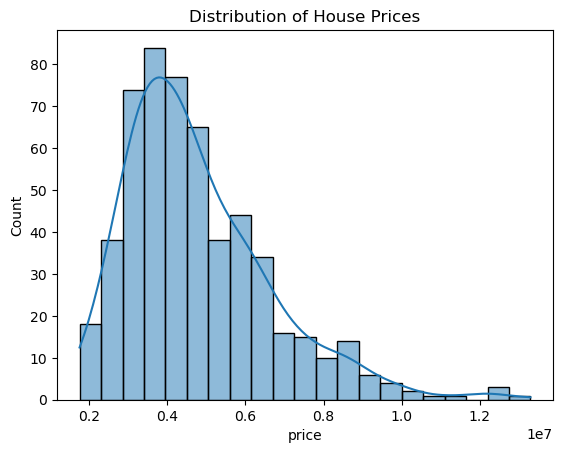

In [ ]:
# Plot a histogram of the target variable (house prices)
sns.histplot(x=df["price"], kde=True)
plt.title("Distribution of House Prices")
plt.show()

The price distribution is right-skewed, with most houses priced between $2M and $7M. A small number of high-value properties extend the tail to the right.

### 4.2 Area vs Price

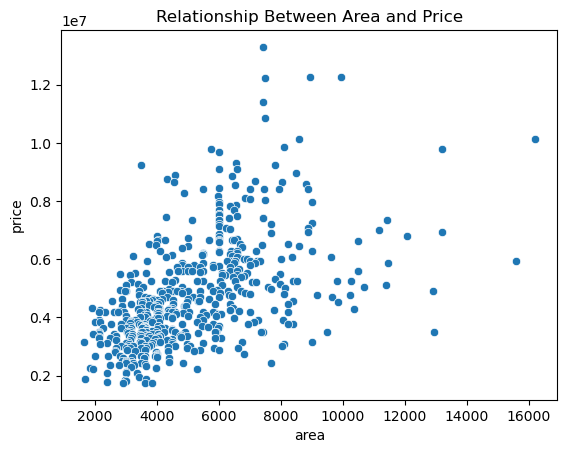

In [7]:
# Plot a scatter plot to visualize the relationship between area and price
sns.scatterplot(x="area", y="price", data=df)
plt.title("Relationship Between Area and Price")
plt.show()

There is a clear positive relationship between area and price, larger houses tend to cost more. However, the spread widens at higher areas, suggesting other features also play a role.

### 4.3 Feature Correlation Heatmap

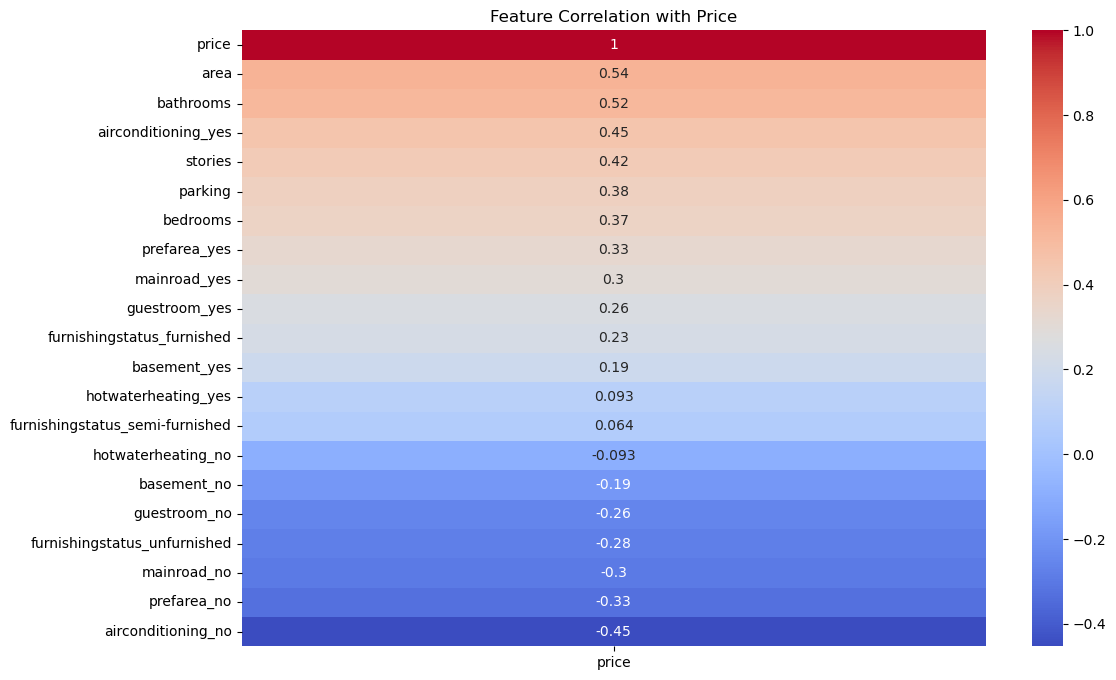

In [8]:
# Plot a heatmap to visualize correlations between features and price
df_encoded = pd.get_dummies(df)
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr()[["price"]].sort_values("price", ascending=False), annot=True, cmap="coolwarm")
plt.title("Feature Correlation with Price")
plt.show()

Area (0.54) and bathrooms (0.52) show the strongest correlations with price among numerical features. No single feature dominates, suggesting that a multi-feature model is necessary for accurate predications.

## 5. Feature Enginerring
I create two new features to capture additional information. total_rooms combines bedrooms and bathrooms, as overall room count may be more predictive than either alone. area_per_room captures how spacious the house is relative to its size.

In [9]:
# Feature engineering: create new features based on existing ones
df["total_rooms"] = df["bedrooms"] + df["bathrooms"]
df["area_per_room"] = df["area"] / (df["total_rooms"] + 1)

## 6. Model Setup
I split the data 80/20 into training and test sets. Numerical features are standardized so that large values like area don't dominate smaller ones like bedrooms. Categorical features are one-hot encoded to convert them into a numerical format the model can use. I use a Pipeline to chain preprocessing and modeling together cleanly.

In [10]:
# Define features and target
X = df.drop("price", axis=1)
y = df["price"]

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify numeric and categorical features
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop='first'), categorical_features)
])

## 7. Modeling & Evaluation
I start with Linear Regression as a baseline model. It is simple, interpretable, and works well when relationships between features and the target are approximately linear.

### 7.1 Linear Regression

In [11]:
# Create a pipeline that combines the preprocessor with a linear regression model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Train the model
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)

# Mean price for reference
mean_price = y_test.mean()

# Print evaluation metrics
print("MAE:", mean_absolute_error(y_test, y_pred))
print(f"MAE as % of mean price: {mean_absolute_error(y_test, y_pred) / mean_price * 100:.1f}%")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print(f"RMSE as % of mean price: {np.sqrt(mean_squared_error(y_test, y_pred)) / mean_price * 100:.1f}%")
print("R2:", r2_score(y_test, y_pred))

MAE: 966254.1084395876
MAE as % of mean price: 19.3%
RMSE: 1313237.0101228138
RMSE as % of mean price: 26.2%
R2: 0.6588055243671118


The Linear Regression model achieves an R2 of 0.66 meaning it explains 66% of the variance in house prices. The MAE is approximately 20% of the mean price, which is reasonable for a dataset of this size.

### 7.2 Predicted vs Actual -- Linear Regression

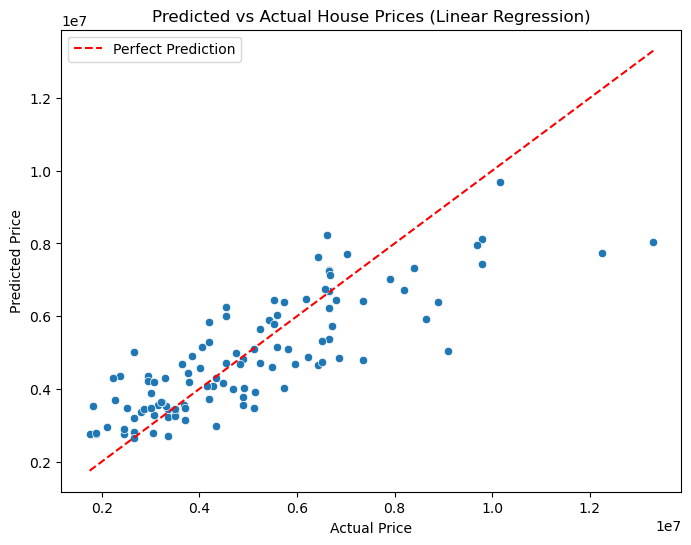

In [12]:
# Plot predicted vs actual prices
plt.figure(figsize=(8, 6))
pred_actual = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
sns.scatterplot(data=pred_actual, x="Actual", y="Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual House Prices (Linear Regression)")
plt.legend()
plt.show()

Points close to the red dashed line indicate accurate predictions. The model performs well in the low to mid-price range but shows more spread at higher prices, suggesting it underestimates expensive houses.

### 7.3 Random Forest Regression

In [13]:
# Create a pipeline that combines the preprocessor with a Random Forest Regressor
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42
    ))
])

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Print evaluation metrics for Random Forest
print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))
print(f"RF MAE as % of mean price: {mean_absolute_error(y_test, y_pred_rf) / mean_price * 100:.1f}%")
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print(f"RF RMSE as % of mean price: {np.sqrt(mean_squared_error(y_test, y_pred_rf)) / mean_price * 100:.1f}%")
print("RF R2:", r2_score(y_test, y_pred_rf))

RF MAE: 1039480.6301919452
RF MAE as % of mean price: 20.8%
RF RMSE: 1399642.4813620534
RF RMSE as % of mean price: 28.0%
RF R2: 0.6124301414063473


The Random Forest underperforms Linear Regression here. With only 545 rows, the dataset may be too small for Random Forest to leverage its complexity effectively. This suggets the relationships in the data are largely linear.

### 7.4 Predicted vs Actual -- Random Forest

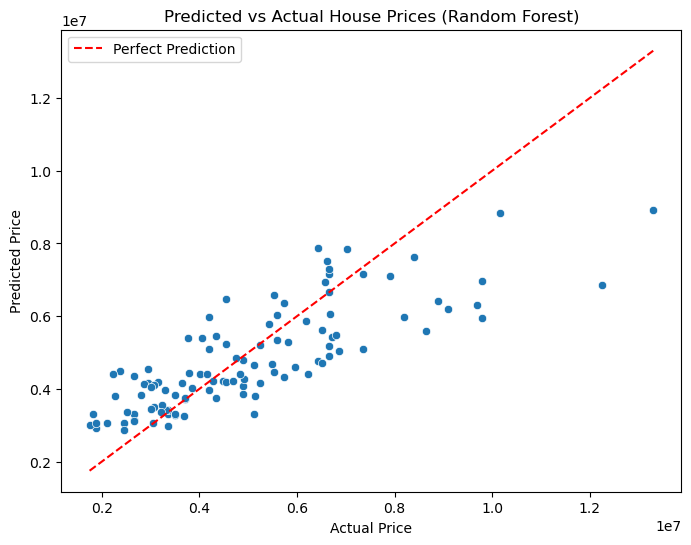

In [14]:
# Plot predicted vs actual prices for Random Forest
plt.figure(figsize=(8, 6))
pred_actual_rf = pd.DataFrame({"Actual": y_test, "Predicted": y_pred_rf})
sns.scatterplot(data=pred_actual_rf, x="Actual", y="Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual House Prices (Random Forest)")
plt.legend()
plt.show()

## 8. Conclusion
The Linear Regression model explained 66% of the variance in house prices with a MAE of roughly 20% of the mean price. Area and bathrooms were the strongest predictors, consistent with the correlation analysis. Notably, Linear Regression outperformed Random Forest, suggesting the relationships in this dataset are largely linear and the dataset size limits the benefit of more complex models. With more data or additional features such as precise location, model performance could be improved further.